# 01 · 股票代币溢价：描述统计

**研究问题**：链上的股票代币（xStocks、Ondo）价格，相对真实美股价格偏离多少？偏离在不同股票、不同链、不同时段（开市 / 休市）有什么差别？

**用法**：从上到下依次运行每个单元格（菜单 *Run → Run All Cells*）。数据每 10 分钟增加一次，重新运行就会得到最新结果。

> 数据：`data/` 文件夹里的 CSV，由 Vultr 服务器每 10 分钟采集一次。双击 `打开Jupyter.bat` 时会自动同步最新数据。

## 0. 准备工作
导入需要的库，并设置图表样式。图表的颜色按固定顺序分配，同一个类别在所有图里颜色一致。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

# 图表样式：中文字体、细线、浅色网格
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # 分类色，固定顺序
MUTED, SHADE = "#898781", "#f0efec"
ISSUER_COLOR = {"xStocks (Backed)": BLUE, "Ondo Global Markets": ORANGE}
CHAIN_COLOR = {"solana": BLUE, "ethereum": ORANGE, "bsc": AQUA}

## 1. 读取数据
把 `data/` 下所有每日 CSV 合并成一张表。每一行 = 某个时刻、某个交易池的一次观测。

In [2]:
DATA_DIR = Path.cwd().parent / "data"
files = sorted(DATA_DIR.glob("*/*/prices_*.csv"))
raw = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
raw["ts_utc"] = pd.to_datetime(raw["ts_utc"], utc=True)
raw["ref_time_utc"] = pd.to_datetime(raw["ref_time_utc"], utc=True)

print(f"读取了 {len(files)} 个文件，共 {len(raw):,} 行")
print(f"时间范围：{raw.ts_utc.min():%Y-%m-%d %H:%M} 到 {raw.ts_utc.max():%Y-%m-%d %H:%M}（UTC）")
print(f"快照次数：{raw.ts_utc.nunique()}，交易池数：{raw.pair_address.nunique()}，股票数：{raw.ticker.nunique()}")
raw.head()

读取了 1 个文件，共 642 行
时间范围：2026-10-03 04:34 到 2026-10-03 16:30（UTC）
快照次数：7，交易池数：94，股票数：13


,ts_utc,ticker,token,issuer,chain,dex,quote,pair_address,price_usd,ref_price,ref_time_utc,market_state,premium_pct,liquidity_usd,volume_h24,txns_h24,trusted_quote,anomaly
0,2026-10-03 04:34:01+00:00,TSLA,TSLAx,xStocks (Backed),solana,raydium,USDC,8aDaBQkTrS6HVMjyc6EZebgdiaXhLYGriDWKWWp1NpFF,370.39,370.59,2026-10-02 20:00:00+00:00,CLOSED,-0.0540,2278290.23,1352244.73,7450,1,0
1,2026-10-03 04:34:01+00:00,TSLA,TSLAx,xStocks (Backed),solana,orca,USDC,9p7abUFv31ycgu9kckvnoqMMvBy67dqTDM2m6HP9xokN,370.43,370.59,2026-10-02 20:00:00+00:00,CLOSED,-0.0432,105558.94,136632.19,3793,1,0
2,2026-10-03 04:34:01+00:00,TSLA,TSLAx,xStocks (Backed),solana,raydium,SOL,CKmjDiqBCRqR8xk5FjnFiQXuCFsGchiLv9YwYVnE5RJ8,370.49,370.59,2026-10-02 20:00:00+00:00,CLOSED,-0.0270,94690.20,79267.58,1519,1,0
3,2026-10-03 04:34:01+00:00,TSLA,TSLAx,xStocks (Backed),solana,raydium,USDC,HHQUnUbmWLrYzkscDY1C3deEFbGtiGBGoHjpANogmvum,370.79,370.59,2026-10-02 20:00:00+00:00,CLOSED,0.0540,441358.64,76851.74,417,1,0
4,2026-10-03 04:34:01+00:00,TSLA,TSLAx,xStocks (Backed),solana,orca,SOL,26UY4D6pBHgxYdPWuBP3sfyc4jJf6qQjPDxCJPhtUx3H,377.97,370.59,2026-10-02 20:00:00+00:00,CLOSED,1.9914,8809.32,2772.61,138,1,0


## 2. 数据清洗
采集时没有删除任何池子，只打了标记。这里按研究需要做三件事：

1. **剔除可疑池子**：报价币不是主流币（`trusted_quote = 0`），或溢价离谱（`anomaly = 1`）
2. **标记深池**：流动性 ≥ 5 万美元的池子价格更可信，后面会单独分析
3. **标记时段**：`market_state` 区分盘前 / 盘中 / 盘后 / 休市；另外标出周末

In [3]:
DEEP_USD = 50_000

df = raw[(raw.trusted_quote == 1) & (raw.anomaly == 0)].copy()
df["deep"] = df.liquidity_usd >= DEEP_USD
df["weekend"] = df.ts_utc.dt.tz_convert("America/New_York").dt.dayofweek >= 5
# 真实股价距离采集时刻多久了（小时）：休市时它是一个"过期"的价格
df["ref_age_h"] = (df.ts_utc - df.ref_time_utc).dt.total_seconds() / 3600

dropped = len(raw) - len(df)
print(f"剔除可疑观测 {dropped} 行（{dropped / len(raw):.1%}），保留 {len(df):,} 行")
print(f"其中深池观测 {df.deep.sum():,} 行")
print("\n各时段的观测数：")
print(df.market_state.value_counts().to_string())

剔除可疑观测 100 行（15.6%），保留 542 行
其中深池观测 264 行

各时段的观测数：
market_state
CLOSED    542


## 3. 描述统计：各股票的溢价分布
`premium_pct` = (代币价格 − 真实股价) ÷ 真实股价 × 100。

- **均值 / 中位数** 为正：代币平均比真实股票贵
- **标准差**：不同池子、不同时刻之间的差异大小
- **p5 / p95**：去掉两端 5% 极端值后的区间

In [4]:
def describe(g):
    p = g.premium_pct
    return pd.Series({
        "观测数": len(p), "池子数": g.pair_address.nunique(),
        "均值%": p.mean(), "中位数%": p.median(), "标准差%": p.std(),
        "p5%": p.quantile(0.05), "p95%": p.quantile(0.95),
    })

by_ticker = df.groupby("ticker").apply(describe, include_groups=False).sort_values("均值%")
by_ticker.round(3)

,观测数,池子数,均值%,中位数%,标准差%,p5%,p95%
ticker,,,,,,,
TSLA,79.0,12.0,-0.338,-0.132,0.730,-1.395,0.204
AMZN,28.0,4.0,0.026,0.020,0.245,-0.254,0.334
GOOGL,63.0,9.0,0.181,0.087,0.275,-0.077,0.873
META,42.0,6.0,0.227,0.239,0.104,0.047,0.376
AAPL,63.0,9.0,0.254,0.195,0.258,-0.060,0.797
COIN,35.0,5.0,0.268,0.224,0.331,-0.202,0.831
QQQ,28.0,4.0,0.328,0.341,0.127,0.153,0.583
NVDA,65.0,10.0,0.450,0.398,0.229,0.146,0.925
SPY,63.0,9.0,0.572,0.625,0.165,0.198,0.727


### 按流动性加权的平均溢价
简单平均会让小池子和大池子同样重要。按流动性加权更接近"市场上大部分资金看到的价格"。

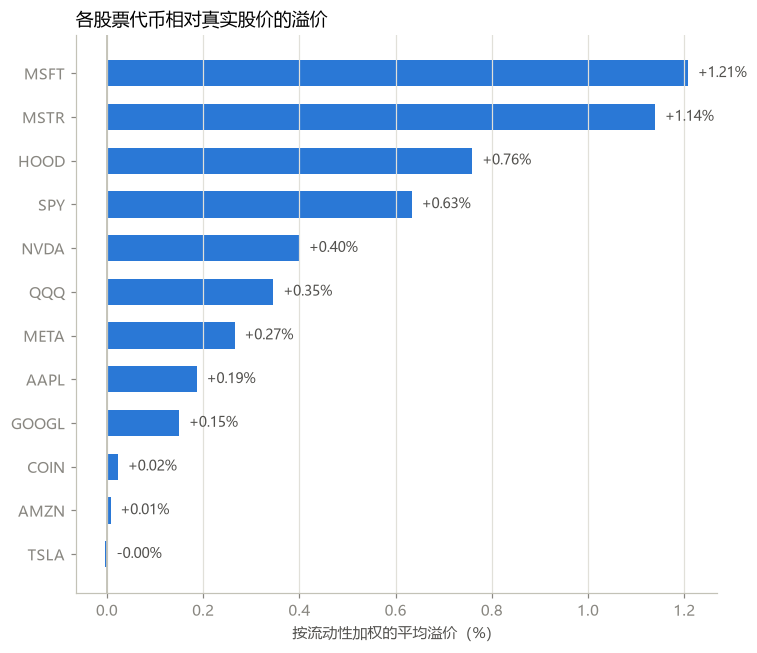

In [5]:
def wavg(g):
    return np.average(g.premium_pct, weights=g.liquidity_usd)

weighted = df.groupby("ticker")[["premium_pct", "liquidity_usd"]].apply(wavg).rename("加权溢价%")
summary = by_ticker[["均值%"]].join(weighted).sort_values("加权溢价%")

fig, ax = plt.subplots(figsize=(7, 0.42 * len(summary) + 1))
ax.barh(summary.index, summary["加权溢价%"], color=BLUE, height=0.6)
ax.axvline(0, color="#c3c2b7", linewidth=1.2)
for y, v in enumerate(summary["加权溢价%"]):
    right = v >= -0.05   # 接近 0 的负值也把标签放右边，避免和股票名重叠
    ax.text(max(v, 0) + 0.02 if right else v - 0.02, y, f"{v:+.2f}%", va="center",
            ha="left" if right else "right", fontsize=9, color="#52514e")
ax.set_xlabel("按流动性加权的平均溢价（%）")
ax.set_title("各股票代币相对真实股价的溢价", loc="left", fontsize=12)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 4. 按发行方、按链比较
同一只股票，xStocks 和 Ondo 两家发行的代币价格是否不同？不同链上呢？

In [6]:
print("按发行方：")
display(df.groupby("issuer").apply(describe, include_groups=False).round(3))
print("按链：")
display(df.groupby("chain").apply(describe, include_groups=False).round(3))

按发行方：


,观测数,池子数,均值%,中位数%,标准差%,p5%,p95%
issuer,,,,,,,
Ondo Global Markets,101.0,16.0,0.034,0.197,0.723,-1.082,1.208
xStocks (Backed),441.0,63.0,0.358,0.291,0.431,-0.072,1.219


按链：


,观测数,池子数,均值%,中位数%,标准差%,p5%,p95%
chain,,,,,,,
bsc,14.0,2.0,0.538,0.651,0.521,-0.291,1.002
ethereum,87.0,14.0,-0.048,0.027,0.720,-1.082,1.208
solana,441.0,63.0,0.358,0.291,0.431,-0.072,1.219


## 5. 开市 vs 休市
这是最核心的问题之一：美股休市时，真实股价"冻结"在收盘价，而代币还在 24 小时交易。
如果休市时溢价的**波动明显更大**，说明代币在消化收盘后的新信息。

⚠️ 数据还少的时候，某些时段可能还没有观测。

In [7]:
state_order = [s for s in ["PRE", "REGULAR", "POST", "CLOSED"] if s in df.market_state.unique()]
by_state = (df.groupby("market_state").apply(describe, include_groups=False)
              .reindex(state_order))
by_state.round(3)

,观测数,池子数,均值%,中位数%,标准差%,p5%,p95%
market_state,,,,,,,
CLOSED,542.0,79.0,0.298,0.283,0.514,-0.68,1.208


## 6. 溢价随时间的变化
每个小图是一只股票，纵轴刻度相同，方便横向比较。线是**每个时刻按流动性加权的平均溢价**，灰色背景 = 美股常规交易时段（纽约时间工作日 9:30–16:00）以外的时间。

采集中断超过 30 分钟的地方，线会断开，避免把缺失的数据"连"出来。

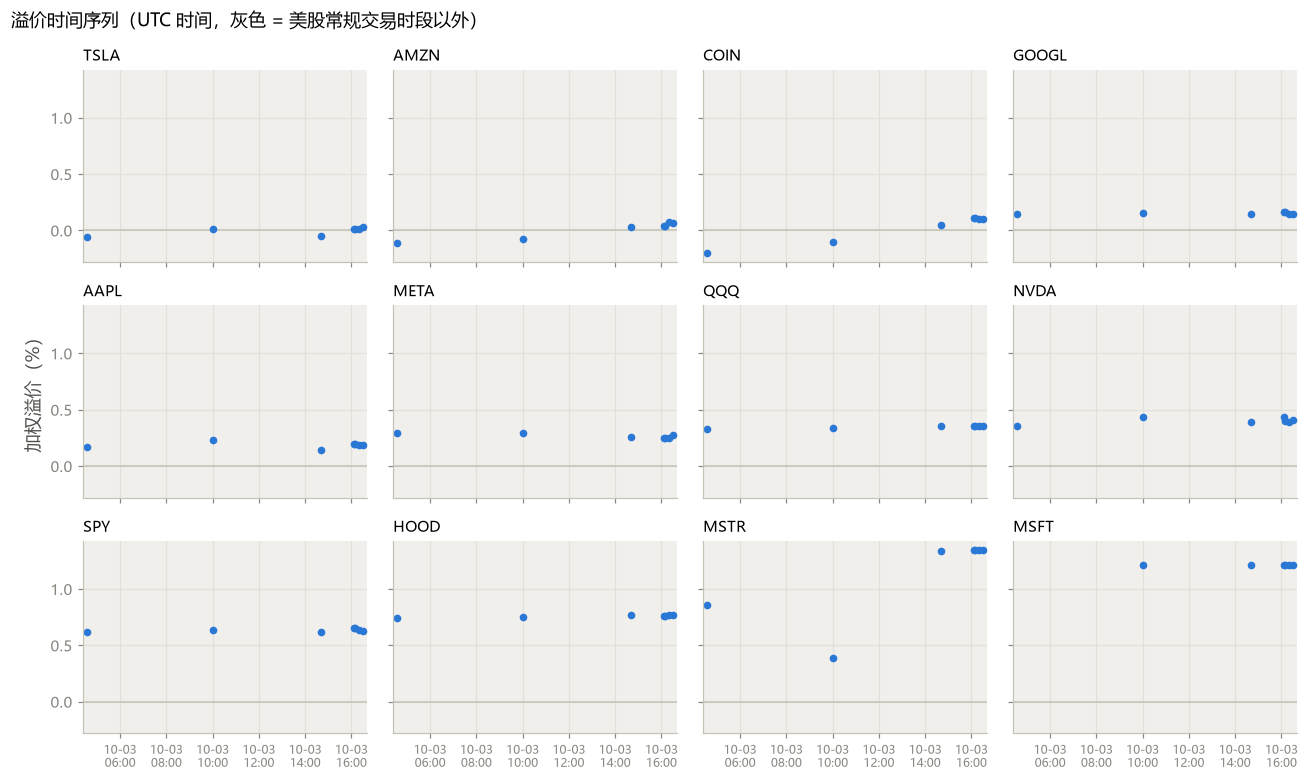

In [8]:
ts = (df.groupby(["ticker", "ts_utc"])[["premium_pct", "liquidity_usd"]]
        .apply(wavg).rename("premium").reset_index())
GAP = pd.Timedelta(minutes=30)
pad = pd.Timedelta(minutes=10)

# 按美股交易时间表算出"非常规交易时段"，用来画灰色背景
# 常规交易时段 = 纽约时间周一到周五 9:30–16:00（这里没有扣除节假日）
ET = "America/New_York"
lo, hi = df.ts_utc.min() - pad, df.ts_utc.max() + pad
days = pd.date_range(lo.tz_convert(ET).normalize(), hi.tz_convert(ET).normalize(), freq="D")
sessions = [(d + pd.Timedelta(hours=9, minutes=30), d + pd.Timedelta(hours=16))
            for d in days if d.dayofweek < 5]
closed_spans, cursor = [], lo
for a, b in sessions:
    a, b = a.tz_convert("UTC"), b.tz_convert("UTC")
    if a > cursor:
        closed_spans.append((cursor, min(a, hi)))
    cursor = max(cursor, b)
if cursor < hi:
    closed_spans.append((cursor, hi))

def with_gaps(s):
    # 相邻两次观测间隔超过 GAP 时插入一个空值，让线在这里断开
    s = s.set_index("ts_utc").premium
    breaks = s.index[1:][np.diff(s.index) > GAP] - pd.Timedelta(seconds=1)
    return pd.concat([s, pd.Series(np.nan, index=breaks)]).sort_index()

tickers = summary.index.tolist()
ncol = 4
nrow = int(np.ceil(len(tickers) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 2.4 * nrow), sharex=True, sharey=True)

for ax, t in zip(axes.flat, tickers):
    for a, b in closed_spans:
        if b > a:
            ax.axvspan(a, b, color=SHADE, linewidth=0)
    ax.set_xlim(lo, hi)
    s = with_gaps(ts[ts.ticker == t])
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.plot(s.index, s.values, color=BLUE, marker="o" if s.notna().sum() < 30 else None, markersize=4)
    ax.set_title(t, loc="left", fontsize=10)
for ax in axes.flat[len(tickers):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
    ax.tick_params(axis="x", labelsize=8)
fig.supylabel("加权溢价（%）", color="#52514e")
fig.suptitle("溢价时间序列（UTC 时间，灰色 = 美股常规交易时段以外）", x=0.01, ha="left", fontsize=12)
plt.tight_layout()
plt.show()

## 7. 池子越深，价格越准吗？
横轴是池子流动性（对数刻度），纵轴是溢价。如果"深池价格更接近真实股价"，点会在右侧向 0 收拢。

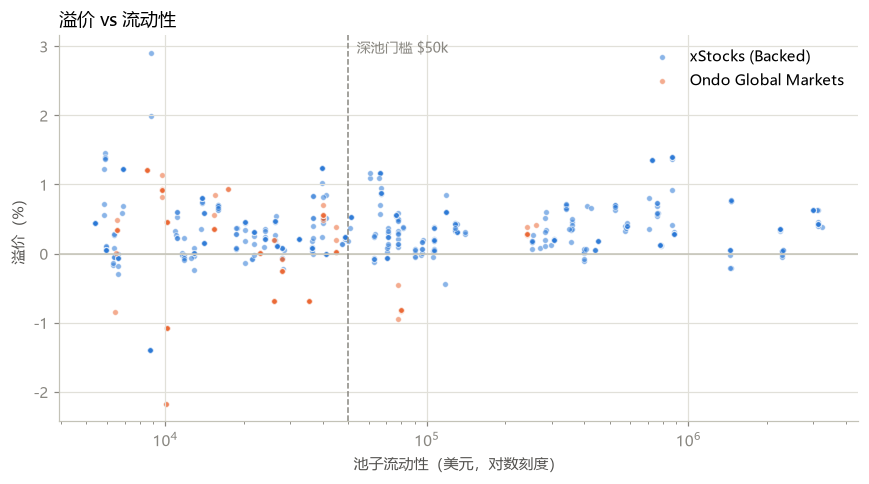

      count   mean    std
deep                     
浅池      278  0.241  0.604
深池      264  0.358  0.390


In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for issuer, color in ISSUER_COLOR.items():
    s = df[df.issuer == issuer]
    ax.scatter(s.liquidity_usd, s.premium_pct, s=14, color=color, alpha=0.55,
               edgecolors="white", linewidths=0.6, label=issuer)
ax.set_xscale("log")
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.axvline(DEEP_USD, color=MUTED, linewidth=1, linestyle="--")
ax.text(DEEP_USD * 1.08, ax.get_ylim()[1] * 0.92, "深池门槛 $50k", fontsize=9, color=MUTED)
ax.set_xlabel("池子流动性（美元，对数刻度）")
ax.set_ylabel("溢价（%）")
ax.set_title("溢价 vs 流动性", loc="left", fontsize=12)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

# 用数字验证：深池和浅池的溢价离散程度
print(df.groupby("deep").premium_pct.agg(["count", "mean", "std"])
        .rename(index={True: "深池", False: "浅池"}).round(3))

## 8. 同一时刻、不同池子之间的价差
对每只股票、每个时刻，计算**深池之间的最高价与最低价之差**。这个价差就是理论上的套利空间（还没扣交易成本）。

In [10]:
deep = df[df.deep]
spread = (deep.groupby(["ticker", "ts_utc"])
              .agg(n=("price_usd", "size"), hi=("price_usd", "max"), lo=("price_usd", "min")))
spread = spread[spread.n >= 2]
spread["spread_pct"] = (spread.hi - spread.lo) / spread.lo * 100

spread.groupby("ticker").spread_pct.agg(["count", "mean", "median", "max"]).sort_values("mean").round(3)

,count,mean,median,max
ticker,,,,
AAPL,7,0.048,0.033,0.147
MSTR,7,0.055,0.043,0.124
QQQ,7,0.056,0.074,0.116
SPY,7,0.185,0.193,0.278
META,7,0.238,0.240,0.279
NVDA,7,0.262,0.295,0.333
COIN,7,0.593,0.559,1.051
HOOD,7,0.767,0.689,0.992
GOOGL,7,0.876,0.953,1.011


## 9. 小结与注意事项

**怎么读这些结果**
- 溢价为正 = 代币比真实股票贵；为负 = 更便宜
- 休市时真实股价是上一次收盘价（看 `ref_age_h` 列），此时的"溢价"其实混合了收盘后的新信息
- SPY、QQQ 等派息资产：代币会把股息再投资进价格，长期看会出现一个缓慢上升的"正溢价"，这不是错误定价

**数据积累后可以做的下一步**
1. **单位根检验（ADF）**：溢价序列是否平稳？平稳说明偏离会回归
2. **协整与 VECM**：代币价格和股价谁在引导谁（价格发现）
3. **周末效应**：周末代币价格变化能否预测周一开盘跳空
4. **价差回归**：用流动性、波动率、时段解释跨池价差